In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("EDAVisualizations") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

sns.set_style("whitegrid")

df = spark.read.parquet("../data/processed/trips_with_disruptions")
print("Rows:", df.count())

26/07/15 16:57:01 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Rows: 765089


# disruption rate by hour:

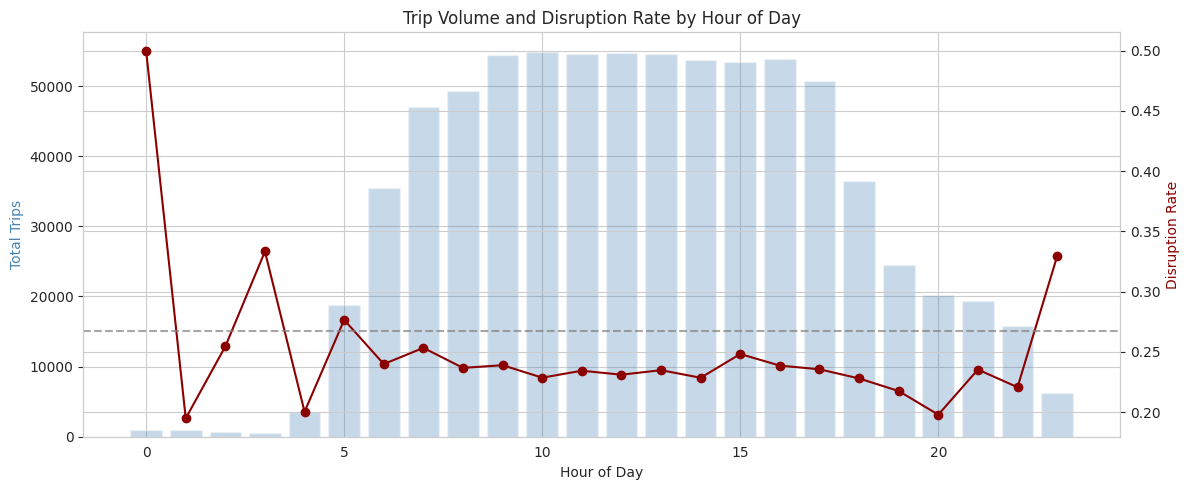

In [2]:
hourly = df.withColumn("departure_hour", F.split(F.col("departure_time"), ":")[0].cast("int")) \
    .groupBy("departure_hour").agg(
        F.count("*").alias("total_trips"),
        F.avg("is_disrupted").alias("disruption_rate")
    ).orderBy("departure_hour").toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly["departure_hour"], hourly["total_trips"], alpha=0.3, color="steelblue", label="Total trips")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total Trips", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(hourly["departure_hour"], hourly["disruption_rate"], color="darkred", marker="o", label="Disruption rate")
ax2.set_ylabel("Disruption Rate", color="darkred")
ax2.axhline(y=0.267, color="gray", linestyle="--", alpha=0.7, label="Overall average (26.7%)")

plt.title("Trip Volume and Disruption Rate by Hour of Day")
fig.tight_layout()
plt.savefig("../outputs/figures/eda_disruption_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# severity distribution:

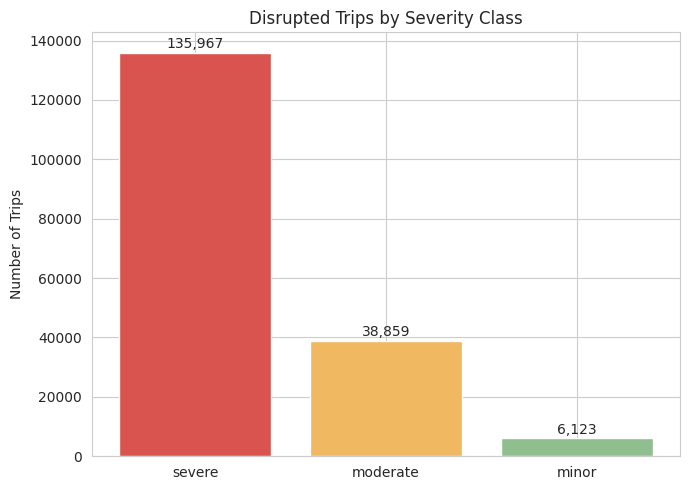

In [3]:
severity_counts = df.filter(F.col("is_disrupted") == 1).groupBy("severity").count().toPandas()

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"minor": "#8fbf8f", "moderate": "#f0b860", "severe": "#d9534f"}
bar_colors = [colors[s] for s in severity_counts["severity"]]
ax.bar(severity_counts["severity"], severity_counts["count"], color=bar_colors)
ax.set_ylabel("Number of Trips")
ax.set_title("Disrupted Trips by Severity Class")
for i, v in enumerate(severity_counts["count"]):
    ax.text(i, v + 1500, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# trip volume by operator:

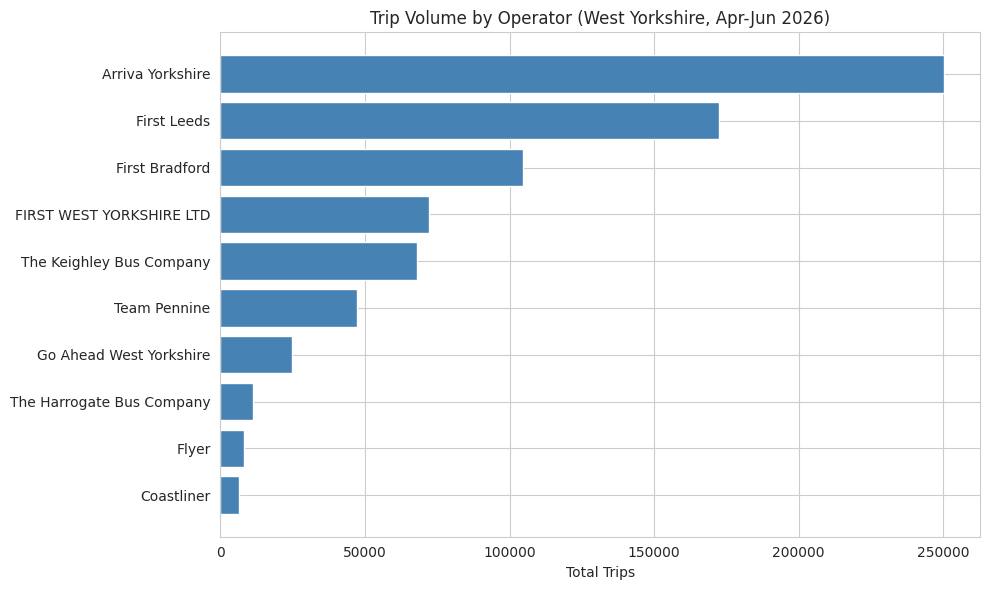

In [4]:
operator_counts = df.groupBy("operator_name").count().orderBy(F.desc("count")).toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(operator_counts["operator_name"], operator_counts["count"], color="steelblue")
ax.set_xlabel("Total Trips")
ax.set_title("Trip Volume by Operator (West Yorkshire, Apr-Jun 2026)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/eda_trips_by_operator.png", dpi=150, bbox_inches="tight")
plt.show()

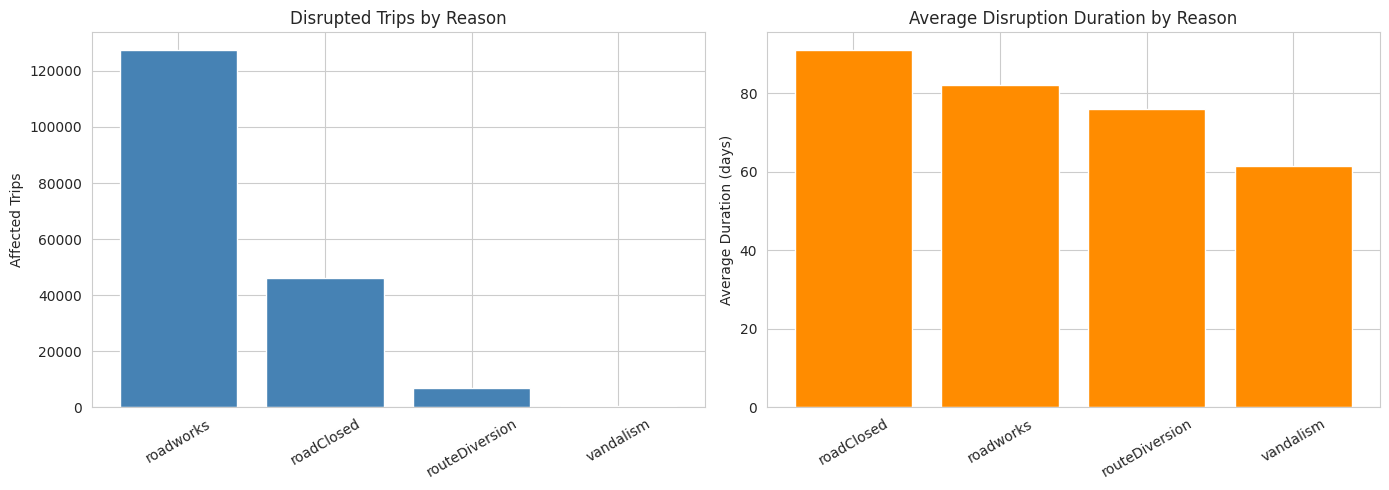

In [5]:
reason_stats = df.filter(F.col("is_disrupted") == 1).groupBy("reason", "planned").agg(
    F.count("*").alias("trip_count"),
    F.avg("overlap_duration_minutes").alias("avg_duration_minutes")
).orderBy(F.desc("trip_count")).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: trip count by reason, split by planned/unplanned
reason_totals = reason_stats.groupby("reason")["trip_count"].sum().sort_values(ascending=False)
axes[0].bar(reason_totals.index, reason_totals.values, color="steelblue")
axes[0].set_ylabel("Affected Trips")
axes[0].set_title("Disrupted Trips by Reason")
axes[0].tick_params(axis='x', rotation=30)

# right: average duration by reason
duration_by_reason = df.filter(F.col("is_disrupted") == 1).groupBy("reason").agg(
    F.avg("overlap_duration_minutes").alias("avg_duration_minutes")
).orderBy(F.desc("avg_duration_minutes")).toPandas()
axes[1].bar(duration_by_reason["reason"], duration_by_reason["avg_duration_minutes"] / 1440, color="darkorange")
axes[1].set_ylabel("Average Duration (days)")
axes[1].set_title("Average Disruption Duration by Reason")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../outputs/figures/eda_disruption_reasons.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis:

In [6]:
from pyspark.sql import functions as F

# statistical distribution shape measures required by the brief,
# calculated directly via PySpark's built-in functions
numeric_cols = ["overlap_duration_minutes"]

for col in numeric_cols:
    stats = df.filter(F.col(col).isNotNull()).select(
        F.mean(col).alias("mean"),
        F.stddev(col).alias("stddev"),
        F.skewness(col).alias("skewness"),
        F.kurtosis(col).alias("kurtosis")
    ).collect()[0]
    print(f"\n{col}:")
    print(f"  Mean:     {stats['mean']:.2f}")
    print(f"  Std Dev:  {stats['stddev']:.2f}")
    print(f"  Skewness: {stats['skewness']:.4f}")
    print(f"  Kurtosis: {stats['kurtosis']:.4f}")


overlap_duration_minutes:
  Mean:     121017.04
  Std Dev:  21731.47
  Skewness: -2.7653
  Kurtosis: 8.6912


# Correlation analysis:

Correlation (departure_hour vs is_disrupted): -0.0122
                departure_hour  is_disrupted
departure_hour        1.000000     -0.005345
is_disrupted         -0.005345      1.000000


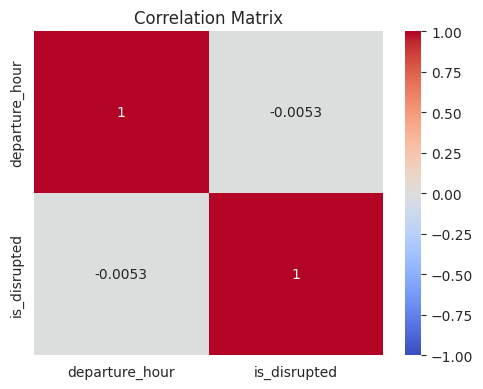

In [7]:
# correlation between numeric features — using departure_hour as a numeric
# proxy since is_disrupted is binary and most other fields are categorical
df_numeric = df.withColumn(
    "departure_hour", F.split(F.col("departure_time"), ":")[0].cast("int")
)

corr_hour_disrupted = df_numeric.stat.corr("departure_hour", "is_disrupted")
print(f"Correlation (departure_hour vs is_disrupted): {corr_hour_disrupted:.4f}")

# build a small correlation matrix for the report
import pandas as pd
sample_pd = df_numeric.select("departure_hour", "is_disrupted").sample(fraction=0.1, seed=42).toPandas()
corr_matrix = sample_pd.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# PySpark SQL queries: 

In [8]:
# demonstrating PySpark SQL directly, as required by the brief
df.createOrReplaceTempView("trips")

result1 = spark.sql("""
    SELECT severity, COUNT(*) as trip_count, ROUND(AVG(overlap_duration_minutes), 2) as avg_duration
    FROM trips
    WHERE is_disrupted = 1
    GROUP BY severity
    ORDER BY trip_count DESC
""")
result1.show()

result2 = spark.sql("""
    SELECT operator_name, 
           COUNT(*) as total_trips, 
           ROUND(AVG(is_disrupted), 4) as disruption_rate
    FROM trips
    GROUP BY operator_name
    ORDER BY disruption_rate DESC
""")
result2.show()

+--------+----------+------------+
|severity|trip_count|avg_duration|
+--------+----------+------------+
|  severe|    135967|   131039.98|
|moderate|     38859|    98876.85|
|   minor|      6123|    38958.65|
+--------+----------+------------+

+--------------------+-----------+---------------+
|       operator_name|total_trips|disruption_rate|
+--------------------+-----------+---------------+
|The Harrogate Bus...|      11219|         0.9884|
|               Flyer|       8086|         0.6029|
|The Keighley Bus ...|      68107|         0.3328|
|        Team Pennine|      47099|         0.3032|
|    Arriva Yorkshire|     250185|         0.2757|
|      First Bradford|     104494|         0.2484|
|Go Ahead West Yor...|      24648|         0.1746|
|         First Leeds|     172458|         0.1312|
|          Coastliner|       6487|         0.0848|
|FIRST WEST YORKSH...|      72306|         0.0778|
+--------------------+-----------+---------------+

